In [30]:
import numpy as np
from scipy.integrate import solve_ivp
import pypesto
import pypesto.optimize as optimize

# -------------------------
# Lotka–Volterra dynamics
# -------------------------
def f(x, th):
    a, b, d, g = th
    x1, x2 = x
    return np.array([a*x1 - b*x1*x2,
                     d*x1*x2 - g*x2])

def integrate(theta, t, x0):
    def rhs(ti, x):
        return f(x, theta)
    sol = solve_ivp(rhs, (t[0], t[-1]), x0, t_eval=t,
                    rtol=1e-7, atol=1e-9)
    return sol.y.T  # shape (len(t), 2)

# -------------------------
# Negative log-likelihood
# -------------------------
def make_objective(t, y, x0, sigma):
    inv_var = 1.0 / (sigma**2)
    def fun(theta):
        X = integrate(theta, t, x0)
        if np.any(X <= 0) or np.any(y <= 0):
            return np.inf
        r = np.log(y) - np.log(X)
        return 0.5 * inv_var * np.sum(r*r)
    return pypesto.Objective(fun=fun), fun

# -------------------------
# Example: synthetic data
# -------------------------
t = np.linspace(0.0, 1.0, 31)
x0 = np.array([30.0, 8.0])
theta_true = np.array([1.5, 0.2, 0.1, 0.9])
sigma = 0.1

X_true = integrate(theta_true, t, x0)
rng = np.random.default_rng(0)
Y = X_true * np.exp(rng.normal(0.0, sigma, X_true.shape))

# -------------------------
# Set up pypesto problem
# -------------------------
obj, fun = make_objective(t, Y, x0, sigma)
lb = [1e-6, 1e-6, 1e-6, 1e-6]
ub = [5.0, 1.0, 1.0, 5.0]
problem = pypesto.Problem(objective=obj, lb=lb, ub=ub,
                          x_names=["alpha", "beta", "delta", "gamma"])

opt = optimize.ScipyOptimizer(method="L-BFGS-B")
res = optimize.minimize(problem, n_starts=5, optimizer=opt)

# -------------------------
# Extract best parameters
# -------------------------
best = int(np.argmin([r["fval"] for r in res.optimize_result.list]))
theta_hat = res.optimize_result.list[best]["x"]

print("theta_hat:", theta_hat) 


100%|██████████| 5/5 [00:01<00:00,  4.05it/s]

theta_hat: [1.10780341 0.16985009 0.10569459 0.93565645]


Initializing betas with "near-exponential decay".
100%|██████████| 20000/20000 [01:35<00:00, 208.40it/s]
Elapsed time: 96.11567951300003
/home/arya/miniconda3/envs/diffsysid/lib/python3.11/site-packages/pypesto/visualize/sampling.py:79: UserWarning: Burn in index not found in the results, the full chain will be shown.
You may want to use, e.g., `pypesto.sample.geweke_test`.
  _, params_fval, _, _, _ = get_data_to_plot(
/home/arya/miniconda3/envs/diffsysid/lib/python3.11/site-packages/pypesto/visualize/sampling.py:1293: UserWarning: Burn in index not found in the results, the full chain will be shown.
You may want to use, e.g., `pypesto.sample.geweke_test`.
  nr_params, params_fval, theta_lb, theta_ub, param_names = get_data_to_plot(


PT posterior mean: [1.11139769 0.17008808 0.10593539 0.94379923]
PT posterior cov:
 [[ 8.04460778e-02  5.31627249e-03 -2.30899160e-04  6.01462416e-03]
 [ 5.31627249e-03  3.65746764e-04 -3.80509305e-05 -5.04824569e-05]
 [-2.30899160e-04 -3.80509305e-05  9.18143800e-05  1.84278234e-03]
 [ 6.01462416e-03 -5.04824569e-05  1.84278234e-03  3.91287038e-02]]


array([[<Axes: xlabel='alpha', ylabel='Density'>,
        <Axes: xlabel='beta', ylabel='Density'>],
       [<Axes: xlabel='delta', ylabel='Density'>,
        <Axes: xlabel='gamma', ylabel='Density'>]], dtype=object)

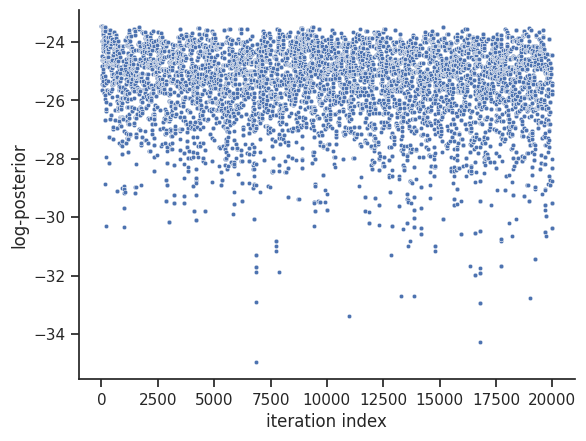

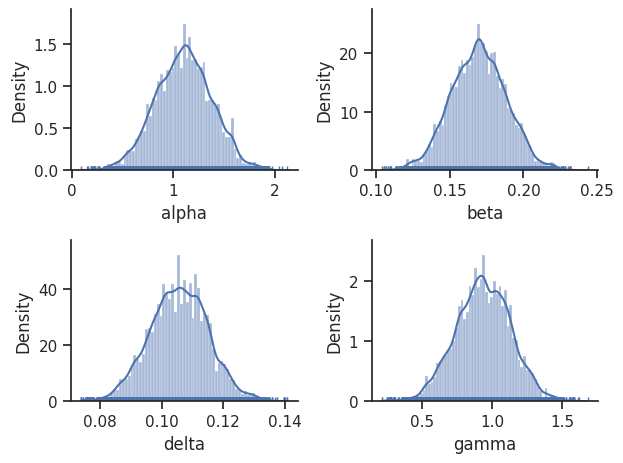

In [31]:
# --- Parallel tempering MCMC (posterior sampling) ---
import pypesto.sample as sample
import pypesto.visualize as viz

# Sampler: adaptive PT with adaptive Metropolis proposals on each chain
pt_sampler = sample.AdaptiveParallelTemperingSampler(
    internal_sampler=sample.AdaptiveMetropolisSampler(),
    n_chains=5  # number of temperatures
)

# Start at MLE (or any feasible point)
x0_pt = theta_hat

# Draw samples: target posterior ∝ exp(-objective.fval(theta))
# objective is negative log-likelihood, bounds = uniform box prior
pt_result = sample.sample(
    problem=problem,
    n_samples=20_000,        # per chain
    sampler=pt_sampler,
    x0=x0_pt,
    filename=None            # or path to store HDF5
)

# Identify the cold chain (beta = 1.0) and extract samples
betas = pt_result.sample_result.betas                   # shape (n_chains,)
cold = int(np.argmax(betas))                            # beta=1.0 is the max
chain = np.asarray(pt_result.sample_result.trace_x[cold])  # shape (n_samples, d)

# Optional: drop burn-in and thin
burn = chain.shape[0] // 2
samples = chain[burn::5]  # 50% burn-in, thin by 5

# Quick summaries
post_mean = samples.mean(axis=0)
post_cov  = np.cov(samples.T)
print("PT posterior mean:", post_mean)
print("PT posterior cov:\n", post_cov)

# Basic diagnostics/plots (if you like)
viz.sampling_fval_traces(pt_result)          # objective traces
viz.sampling_1d_marginals(pt_result)         # per-parameter marginals (cold chain)
# viz.sampling_parameter_traces(pt_result)   # parameter traces
